## Binary Classification Problem: Fake News Dataset

In this notebook, we will use preprocessed data from Kaggle, available in the following link: https://www.kaggle.com/datasets/omchannawar001/processed-fake-news-dataset-csv

This data is organized in rows, the ones we will use are **label** and **processed text**. The label is 0 for fake news and 1 for real news. Processed text is the content of the article in all lowercase and cleaning extra spaces or special characters.

First we'll need to pass the data from the csv file into python arrays that can be used to train the ML algorithm. We'll use 80% of the articles as the training set and 20% will be left for test time.

The main steps are the following:

1. Processing the data:
* Import and store the data into variables
* Count the number of times each word appears among all articles in the training set
* Create an array of the most common words
* Define the input matrix X and the output vector y

2. Logistic Regression:
* Define the sigmoid and the hypothesis functions
* Define the gradient descent algorithm and the cost function
* Initialize the parameters and run the algorithm
* Keep track of the cost function at each iteration

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Processing the data

In [3]:
data = pd.read_csv('/Users/amanda_437/Downloads/Processed Fake News Dataset.csv')

processed_txt = data['processed_text'][:35748] #80% of the data
label = data['label'][:35748]

In [4]:
all_words = []

# Creates list of all the words of all the articles together
for article in processed_txt:
    words = article.split()
    all_words.extend(words) #extend adds to the existing list instead of appending a new list

In [5]:
from collections import Counter
num_most_common = 500 #features: 500 most common words

word_counts = Counter(all_words) #dictionay of {word, frequency} pairs
most_common_words = [word for word, count in word_counts.most_common(num_most_common)] 

# Glossary of words
word_to_index = {
    word: i+1 for i, word in enumerate(most_common_words) #starts at 1, not 0, to match the input matrix X indices
}

In [6]:
m = len(processed_txt)
n = len(most_common_words)

X = np.zeros((m, n+1))

for i, article in enumerate(processed_txt):
    counts = Counter(article.split())

    for word, count in counts.items():
        if word in word_to_index:
            X[i, word_to_index[word]] = count

X[:, 0] = 1

y = label.values.reshape(m, 1)

### Logistic Regression

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def hypothesis(X, theta):
    return sigmoid(X @ theta)

def cost_function(X, y, theta):
    h = hypothesis(X, theta)
    log_likelihood = y * np.log(h) + (1-y) * np.log(1-h)
    return -np.mean(log_likelihood)

def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        errors = hypothesis(X, theta) - y
        theta = theta - (alpha / m) * X.T @ errors
        cost_history.append(cost_function(X, y, theta))
        
    return theta, cost_history

In [8]:
theta0 = np.zeros((n+1, 1)) #initial parameter value
alpha = 0.1 #learning rate
iterations = 500

theta, cost_history = gradient_descent(X, y, theta0, alpha, iterations)

## Plotting and Analysis
With the trained model in hand, we can observe and analyze the resulting correlations, and also evaluate the model's performance.

Let's start by computing the accuracy of the model based on the training set (data it was given previously). We do that by computing the hypothesis function and turning that into a 0 or a 1 to get the algorithm's prediction. Then, we compare that to the actual value for each article.

In [9]:
h = hypothesis(X, theta)
y_pred = (h >= 0.5).astype(int) #1 for real news and 0 for fake news
accuracy = np.mean(y_pred == y)
print(f'Accuracy of {accuracy * 100:.2f}%')

Accuracy of 99.21%


Let's now look at the words that most impact the classification of real or fake news. By sorting the parameters in ascending order, we can get the words that most indicate a real new (highest parameter values), and the ones that most indicate a fake new (lowest parameter values). Let's organize this data using Pandas' `DataFrame` for better view and to easily export it (in case we want to do that).

In [10]:
weights = theta[1:,0] #Start from 1 and not 0 since 0 is the extra parameters
num_words = 100

# Code for words indicating real news
idx_real = np.argsort(weights)[-num_words:] #Sort the indices in ascending order rather than changing the original array 
real_word_list = []
real_weight_list = []

for i in idx_real[::-1]:
    real_word_list.append(most_common_words[i])
    real_weight_list.append(f'{weights[i]:.2f}')

data_real = {
    'Words indicating Real' : real_word_list,
    'Weights': real_weight_list
}

df_real = pd.DataFrame(data_real)

# Code for words indicating fake news
idx_fake = np.argsort(weights)[:num_words]
fake_word_list = []
fake_weight_list = []

for i in idx_fake:
    fake_word_list.append(most_common_words[i])
    fake_weight_list.append(f'{weights[i]:.2f}')

data_fake = {
    'Words indicating Fake' : fake_word_list,
    'Weights': fake_weight_list
}

df_fake = pd.DataFrame(data_fake)

# Combine the DataFrames to print
combined_df = pd.concat([df_real, df_fake], axis = 1)
combined_df.to_csv('Words_Weights_Model1.csv', index = False)

print(combined_df[:10])

  Words indicating Real Weights Words indicating Fake Weights
0               reuters    1.73              politics   -0.77
1          politicsnews    0.96                 video   -0.70
2             worldnews    0.75              leftnews   -0.54
3                  said    0.40                   via   -0.49
4              minister    0.22                  news   -0.49
5             wednesday    0.20                 image   -0.45
6                friday    0.20               hillary   -0.39
7            washington    0.20                  like   -0.27
8              thursday    0.19                   gop   -0.27
9               tuesday    0.19                  even   -0.26


From those rankings of most influential words, some hypothesis may be ellaborated. First, notice that there are certain 'accuracy inflator' words, that is, words that easily indicate a fake or a real new, but won't always be part of articles (they are metadata rather than linguistic evidence). For instance, the word 'reuters' almost instantly validates the article since Reuters is a renowed international news agency. Words like 'politics', 'leftnews' and 'worldnews' are different categories of articles, not being adequate factors to judge an article real or fake.

In contrast, some words in those rankings seem to make sense when analyzed. Words like 'minister', 'representative', and 'leader' indicate the presence (or participation) of a figure of authority in the matter discussed, this tends to increase the probability of the article to be real. However, words like 'via', 'image', and 'video' are often used in fake articles, most likely to cite secondary, informal sources, which can be social media (for example: 'via a video shared on Twitter').

In [11]:
# Quick line of code to find the index for a word or vice-versa
print([(k, v) for k, v in word_to_index.items() if (k == '0' or v == 0)])

[]


In the next cell, we will write the code to generate a 2D scatterplot that shows 2 features (one on each axis) and the classification of real vs fake by the color/format of the point. This is mainly to understand what is being done by the model rather than to draw conclusions: we have 500 features, looking at only 2 of them isn't effective to determine the trends and correlations.

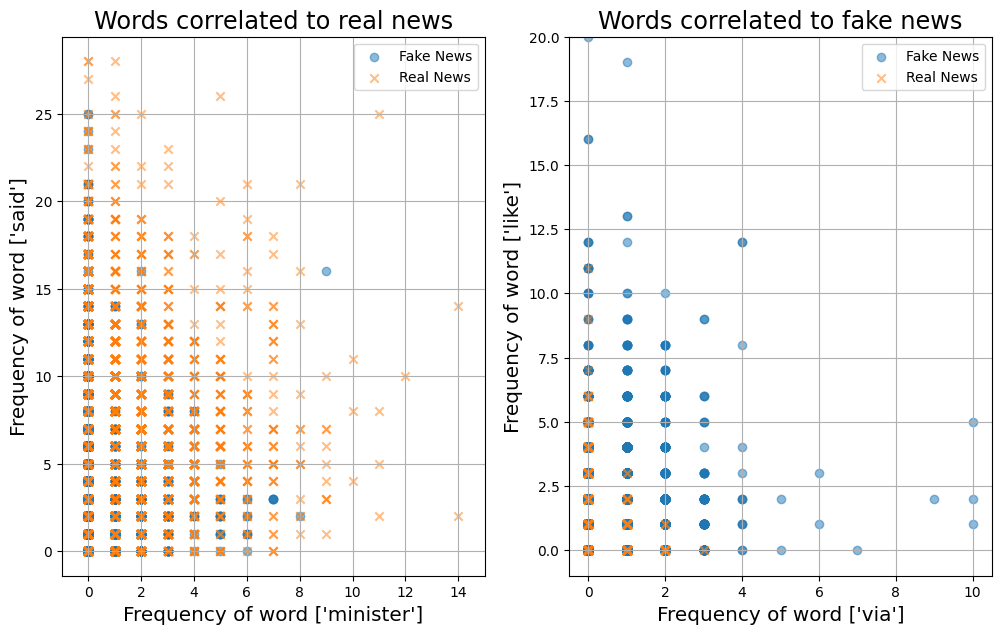

In [12]:
real = y[:, 0] == 1
fake = y[:, 0] == 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7))

# Words correlated to real news
feature_x_ax1 = 115
feature_y_ax1 = 2

ax1.scatter(X[fake, feature_x_ax1], X[fake, feature_y_ax1], marker = 'o', label = 'Fake News', alpha = 0.5)
ax1.scatter(X[real, feature_x_ax1], X[real, feature_y_ax1], marker = 'x', label = 'Real News', alpha = 0.5)

ax1.set_xlabel(f'Frequency of word {[k for k, v in word_to_index.items() if v == feature_x_ax1]}', fontsize = 'x-large')
ax1.set_ylabel(f'Frequency of word {[k for k, v in word_to_index.items() if v == feature_y_ax1]}', fontsize = 'x-large')
ax1.legend()
ax1.set_xlim(-1,15)
ax1.set_title('Words correlated to real news', fontsize = 'xx-large')
ax1.grid()

#Words correlated to fake news
feature_x_ax2 = 107
feature_y_ax2 = 30

ax2.scatter(X[fake, feature_x_ax2], X[fake, feature_y_ax2], marker = 'o', label = 'Fake News', alpha = 0.5)
ax2.scatter(X[real, feature_x_ax2], X[real, feature_y_ax2], marker = 'x', label = 'Real News', alpha = 0.5)

ax2.set_xlabel(f'Frequency of word {[k for k, v in word_to_index.items() if v == feature_x_ax2]}', fontsize = 'x-large')
ax2.set_ylabel(f'Frequency of word {[k for k, v in word_to_index.items() if v == feature_y_ax2]}', fontsize = 'x-large')
ax2.legend()
ax2.set_ylim(-1, 20)
ax2.set_title('Words correlated to fake news', fontsize = 'xx-large')
ax2.grid()

plt.show()

The features used in the plots are some of the highest ranking of each category, selected by hand to avoid those 'accuracy inflator' words. The plots use the known data (whether the article is real or fake), so that we can see if the model is classifying them right.

We can also plot the cost over the iterations to see the progress of the model until convergence:

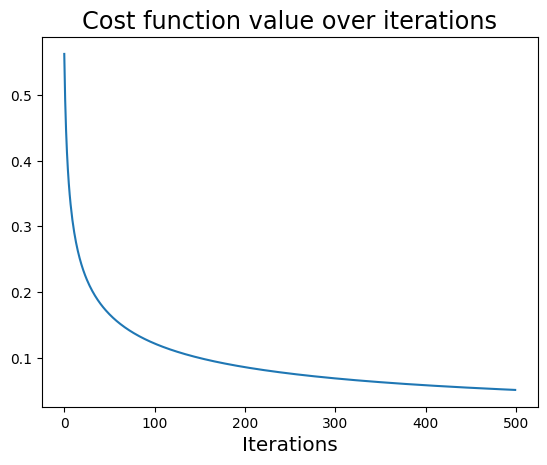

In [13]:
plt.plot(cost_history)
plt.title('Cost function value over iterations', fontsize = 'xx-large')
plt.xlabel('Iterations', fontsize = 'x-large')
plt.show()

## Next Steps

* Clean the list of words before picking the most common to remove the 'accuracy inflators'
* Build a second model on this updated list and compare its performance with the first one
* Test both models with the articles not used for training
* Compare the performance of both models (train accuracy vs test accuracy) and the test accuracy of one model vs the other